In [1]:
!pip install -U mediapipe opencv-python-headless scikit-learn pandas matplotlib --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 77.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 28.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 94.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 98.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 8.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires matplotlib<=3

In [2]:
import os
import urllib.request

MODEL_PATH = "pose_landmarker_lite.task"
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task"

if not os.path.exists(MODEL_PATH):
    print("Downloading pose landmarker model...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Downloaded.")
else:
    print("Model already present.")

print("Model file size:", os.path.getsize(MODEL_PATH), "bytes")


Downloaded.
Model file size: 5777746 bytes


In [3]:
DATASET_ROOT = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset"

def print_tree(root, max_depth=3, max_items=15):
    for dirpath, dirnames, filenames in os.walk(root):
        depth = dirpath[len(root):].count(os.sep)
        if depth > max_depth:
            dirnames[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{os.path.basename(dirpath) or dirpath}/")
        for fn in filenames[:max_items]:
            print(f"{indent}  {fn}")
        if len(filenames) > max_items:
            print(f"{indent}  ... ({len(filenames)} files total)")

if os.path.exists(DATASET_ROOT):
    print_tree(DATASET_ROOT)
else:
    print("Path not found. Available paths under /kaggle/input:")
    for root, dirs, files in os.walk("/kaggle/input"):
        print(root)


ur-fall-detection-dataset/
  UR_fall_detection_dataset_cam0_rgb/
    adl-07-cam0-rgb/
      adl-07-cam0-rgb-057.png
      adl-07-cam0-rgb-034.png
      adl-07-cam0-rgb-178.png
      adl-07-cam0-rgb-126.png
      adl-07-cam0-rgb-002.png
      adl-07-cam0-rgb-103.png
      adl-07-cam0-rgb-153.png
      adl-07-cam0-rgb-174.png
      adl-07-cam0-rgb-051.png
      adl-07-cam0-rgb-096.png
      adl-07-cam0-rgb-128.png
      adl-07-cam0-rgb-065.png
      adl-07-cam0-rgb-089.png
      adl-07-cam0-rgb-038.png
      adl-07-cam0-rgb-024.png
      ... (180 files total)
    adl-32-cam0-rgb/
      adl-32-cam0-rgb-042.png
      adl-32-cam0-rgb-015.png
      adl-32-cam0-rgb-039.png
      adl-32-cam0-rgb-102.png
      adl-32-cam0-rgb-117.png
      adl-32-cam0-rgb-189.png
      adl-32-cam0-rgb-009.png
      adl-32-cam0-rgb-057.png
      adl-32-cam0-rgb-111.png
      adl-32-cam0-rgb-195.png
      adl-32-cam0-rgb-158.png
      adl-32-cam0-rgb-049.png
      adl-32-cam0-rgb-046.png
      adl-32-cam0-rgb-130

In [4]:
IMAGE_EXTS = (".png", ".jpg", ".jpeg")

all_images = []
for dirpath, dirnames, filenames in os.walk(DATASET_ROOT):
    for fn in filenames:
        if fn.lower().endswith(IMAGE_EXTS):
            all_images.append(os.path.join(dirpath, fn))

print(f"Found {len(all_images)} candidate image files.")

def label_from_path(path):
    lower = path.lower()
    if "fall" in lower and "adl" not in lower:
        return "fall"
    elif "adl" in lower or "normal" in lower:
        return "normal"
    return None

def sequence_id_from_path(path):
    return os.path.basename(os.path.dirname(path))

records = []
for img_path in all_images:
    label = label_from_path(img_path)
    if label is None:
        continue
    records.append({"path": img_path, "label": label, "sequence_id": sequence_id_from_path(img_path)})

print(f"Labeled {len(records)} images "
      f"({sum(r['label']=='fall' for r in records)} fall, "
      f"{sum(r['label']=='normal' for r in records)} normal)")

if len(records) == 0:
    print("\nNo images auto-labeled -- check the folder tree above and adjust "
          "label_from_path()/sequence_id_from_path().")


Found 11936 candidate image files.
Labeled 11936 images (2995 fall, 8941 normal)


In [6]:
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

NOSE, L_SHOULDER, R_SHOULDER, L_HIP, R_HIP = 0, 11, 12, 23, 24
FEATURE_NAMES = ["torso_angle", "aspect_ratio", "shoulder_hip_dy",
                 "nose_hip_dy", "shoulder_width", "hip_width"]

base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
options = mp_vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.IMAGE,
    num_poses=1,
)
detector = mp_vision.PoseLandmarker.create_from_options(options)


def extract_features(landmarks, w, h):
    def pt(i):
        return np.array([landmarks[i].x * w, landmarks[i].y * h])

    ls, rs = pt(L_SHOULDER), pt(R_SHOULDER)
    lh, rh = pt(L_HIP), pt(R_HIP)
    nose = pt(NOSE)

    shoulder_mid = (ls + rs) / 2
    hip_mid = (lh + rh) / 2

    vec = hip_mid - shoulder_mid
    vertical = np.array([0, 1])
    cos_angle = np.dot(vec, vertical) / (np.linalg.norm(vec) * np.linalg.norm(vertical) + 1e-6)
    torso_angle = np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

    xs = [lm.x * w for lm in landmarks]
    ys = [lm.y * h for lm in landmarks]
    bw, bh = max(xs) - min(xs), max(ys) - min(ys)
    aspect_ratio = bw / bh if bh > 0 else 0

    shoulder_hip_dy = abs(shoulder_mid[1] - hip_mid[1])
    nose_hip_dy = abs(nose[1] - hip_mid[1])
    shoulder_width = np.linalg.norm(ls - rs)
    hip_width = np.linalg.norm(lh - rh)

    return [torso_angle, aspect_ratio, shoulder_hip_dy, nose_hip_dy, shoulder_width, hip_width]


rows = []
skipped_no_person = 0

for i, rec in enumerate(records):
    img_bgr = cv2.imread(rec["path"])
    if img_bgr is None:
        continue
    h, w = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

    result = detector.detect(mp_image)

    if not result.pose_landmarks:
        skipped_no_person += 1
        continue

    landmarks = result.pose_landmarks[0]
    feats = extract_features(landmarks, w, h)
    rows.append(feats + [rec["label"], rec["sequence_id"]])

    if (i + 1) % 200 == 0:
        print(f"Processed {i+1}/{len(records)} images...")

df = pd.DataFrame(rows, columns=FEATURE_NAMES + ["label", "sequence_id"])
print(f"\nDone. {len(df)} images had a detectable pose "
      f"({skipped_no_person} skipped -- no person detected).")
df.to_csv("ur_fall_features.csv", index=False)
df["label"].value_counts()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784012241.955997     147 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784012241.997825     149 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784012242.081345     148 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Processed 200/11936 images...
Processed 400/11936 images...
Processed 600/11936 images...
Processed 800/11936 images...
Processed 1600/11936 images...
Processed 2000/11936 images...
Processed 2200/11936 images...
Processed 3000/11936 images...
Processed 3200/11936 images...
Processed 3400/11936 images...
Processed 3600/11936 images...
Processed 4200/11936 images...
Processed 4400/11936 images...
Processed 4600/11936 images...
Processed 4800/11936 images...
Processed 5400/11936 images...
Processed 5800/11936 images...
Processed 6000/11936 images...
Processed 6200/11936 images...
Processed 6600/11936 images...
Processed 6800/11936 images...
Processed 7000/11936 images...
Processed 7200/11936 images...
Processed 7400/11936 images...
Processed 7800/11936 images...
Processed 8200/11936 images...
Processed 8600/11936 images...
Processed 8800/11936 images...
Processed 9000/11936 images...
Processed 9200/11936 images...
Processed 9400/11936 images...
Processed 9600/11936 images...
Processed 10

label
normal    6389
fall      2531
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert to plain Python lists first -- avoids a pandas/pyarrow indexing bug
# on some Kaggle pandas versions when splitting directly on a pandas Index.
sequence_labels = df.groupby("sequence_id")["label"].first()
seq_ids = list(sequence_labels.index)
seq_label_values = list(sequence_labels.values)

try:
    train_seqs, test_seqs = train_test_split(
        seq_ids, test_size=0.25, random_state=42, stratify=seq_label_values
    )
except ValueError as e:
    print(f"Stratified split failed ({e}); falling back to a plain random split.")
    train_seqs, test_seqs = train_test_split(seq_ids, test_size=0.25, random_state=42)

train_seqs, test_seqs = set(train_seqs), set(test_seqs)

train_df = df[df["sequence_id"].isin(train_seqs)]
test_df = df[df["sequence_id"].isin(test_seqs)]

X_train, y_train = train_df[FEATURE_NAMES], train_df["label"]
X_test, y_test = test_df[FEATURE_NAMES], test_df["label"]

print(f"Train: {len(X_train)} frames from {len(train_seqs)} sequences")
print(f"Test:  {len(X_test)} frames from {len(test_seqs)} sequences")

Train: 6822 frames from 52 sequences
Test:  2098 frames from 18 sequences


Accuracy: 0.777

              precision    recall  f1-score   support

        fall       0.65      0.67      0.66       671
      normal       0.84      0.83      0.83      1427

    accuracy                           0.78      2098
   macro avg       0.74      0.75      0.75      2098
weighted avg       0.78      0.78      0.78      2098



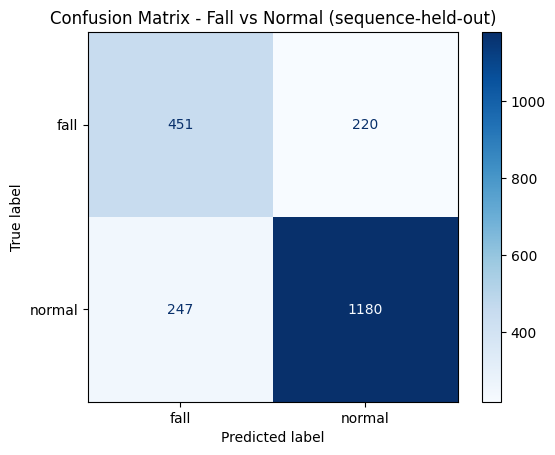

In [11]:
model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(cmap="Blues")
plt.title("Confusion Matrix - Fall vs Normal (sequence-held-out)")
plt.show()


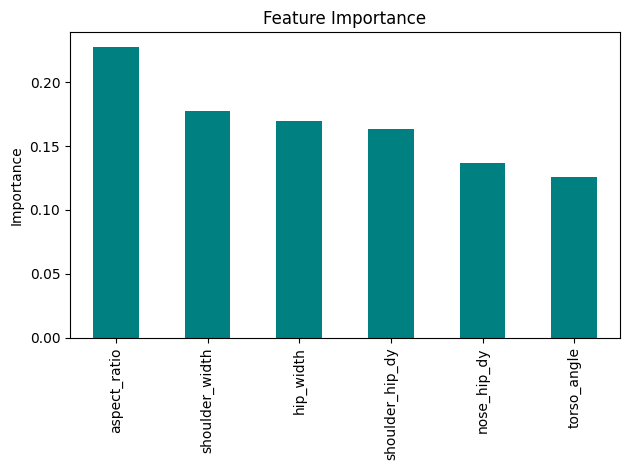

aspect_ratio       0.227662
shoulder_width     0.177375
hip_width          0.169371
shoulder_hip_dy    0.163589
nose_hip_dy        0.136628
torso_angle        0.125375
dtype: float64


In [12]:
importances = pd.Series(model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
importances.plot(kind="bar", title="Feature Importance", color="teal")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()
print(importances)


In [13]:
import pickle

with open("fall_classifier.pkl", "wb") as f:
    pickle.dump(model, f)
print("Saved fall_classifier.pkl -- download it from this notebook's Output panel.")


Saved fall_classifier.pkl -- download it from this notebook's Output panel.
